# Exploration of datasets
## PAN 2023

In [149]:
import os, sys
from nltk.stem.snowball import SnowballStemmer
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_from_disk
sys.path.append(os.path.abspath(".."))
from config import CONFIG
from genai_detection.detectors.impostor import ImpostorDetector

In [150]:
ds_pan = load_from_disk(os.path.join(os.path.abspath(".."), CONFIG.PATH2PAN23))['train'].to_pandas()
labels = ds_pan['same']
display(ds_pan.head())

,id,discourse_types,pair,same,authors
0,a0e656a3-955e-44f6-b5b3-dfd6e360a962,"[email, speech_transcription]",[I think I have decided with regards to the <t...,True,"[en_7, en_7]"
1,c42efa75-f418-4fac-80ca-4d0982704d25,"[email, speech_transcription]","[Dear <addr10_NN>, <nl><nl>If I was to go with...",True,"[en_31, en_31]"
2,a3a6745f-af62-4889-af49-93ec88594142,"[interview, email]","[So, erm, so I’m, erm, I’m actually from <cou...",True,"[en_88, en_88]"
3,244235f3-4647-4ed3-b078-60a2ea2850b7,"[email, speech_transcription]","[Hi <addr2_FN><nl><nl>This is my picture, that...",False,"[en_27, en_38]"
4,d410b3f0-b331-48ab-a524-c29ed1d487a2,"[interview, email]","[Oh, okay. Erm, well, I think of myself as kin...",False,"[en_87, en_32]"


In [151]:
labels.value_counts()

same
True     4418
False    4418
Name: count, dtype: int64

In [152]:
authors = ds_pan['authors'].tolist()
authors = [s for item in authors for s in item.flatten().tolist() if isinstance(item, np.ndarray)]

pairs = ds_pan['pair'].tolist()
texts = [s for item in pairs for s in item.flatten().tolist() if isinstance(item, np.ndarray)]
#pairs

In [153]:


def plot_text_length_histogram(text_list, bins=10, preprocessed:bool = False):
    """
    Plots a histogram of text lengths (in characters) for a list of strings.

    Args:
        text_list (list): List of strings.
        bins (int): Number of bins in the histogram.
    """
    lengths = [len(text) for text in text_list]
    unit = 'characters' if type(lengths[0]) is str else 'ngrams'
    
    plt.figure(figsize=(10, 6))
    plt.hist(lengths, bins=bins, color='skyblue', edgecolor='black')
    title = 'Histogram of Text Lengths (Stemmed)' if preprocessed else 'Histogram of Text Lengths'
    plt.title(title)
    plt.xlabel(f'Text Length ({unit})')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

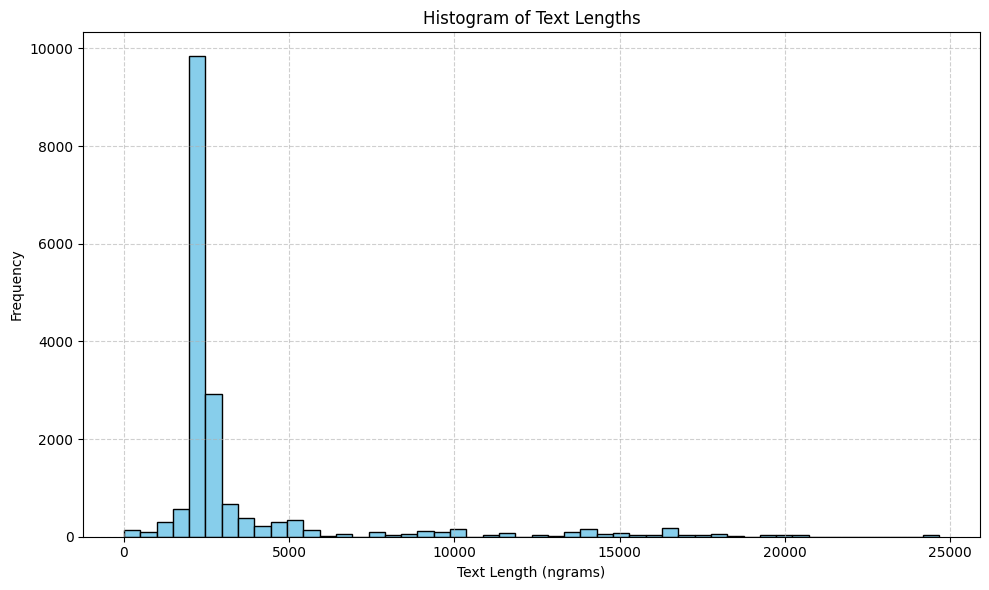

Average length (characters) per text: 3496.74


In [154]:
plot_text_length_histogram(texts, bins=50)
avg_len = np.mean([len(text) for text in texts])
print(f"Average length (characters) per text: {avg_len:.2f}")

In [155]:
def normalize_text(text):
    stemmer = SnowballStemmer('english')
    return ' '.join(stemmer.stem(w) for w in text.lower().split())

In [156]:
# plot_text_length_histogram([normalize_text(p) for p in pairs], bins=50, preprocessed=True)

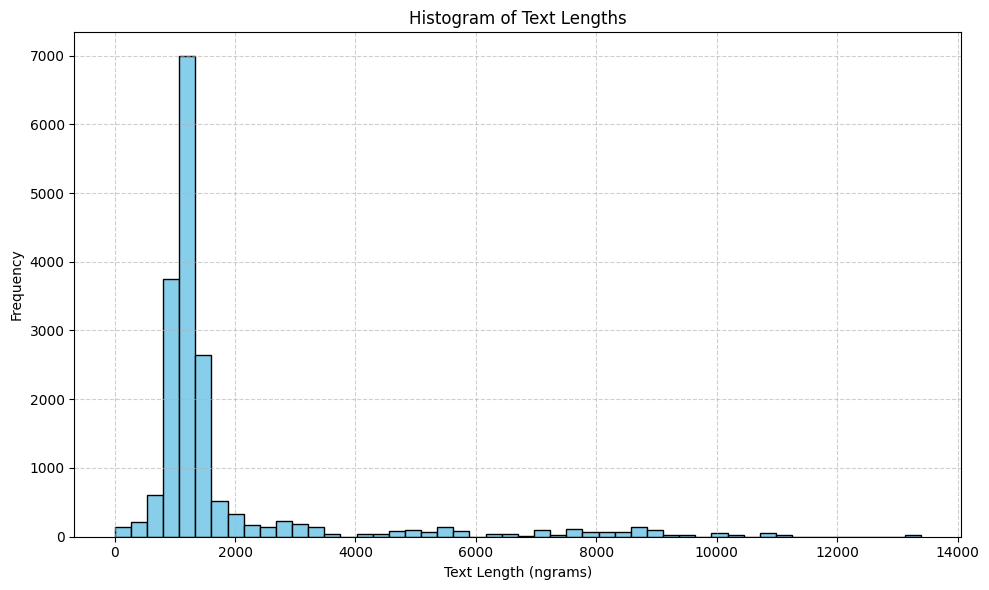

Average number of 4-grams per text: 1815.37


In [157]:
impostor_det = ImpostorDetector(ds_pan, top_n=250, portion_delete=0.5, shared_vocab_only=True, strict=True)
# list of lists of 4-grams
four_grams = [impostor_det.tokenize_char_ngrams(t, n=4, normalize_ws=True, space_free=True) for t in texts]
plot_text_length_histogram(four_grams, bins=50, preprocessed=False)
avg_n_four_grams = np.mean([len(ng) for ng in four_grams])
print(f"Average number of 4-grams per text: {avg_n_four_grams:.2f}")

In [158]:
df_auth_text = pd.DataFrame({'author':authors, 'text':texts})

In [159]:
def plot_avg_text_length_per_author(df, unit='characters'):
    """
    Plots a bar chart of average text length per author.

    Args:
        df (pd.DataFrame): DataFrame with 'author' and 'text' columns.
    """
    if unit == 'ngrams':
        impostor_det = ImpostorDetector(ds_pan, top_n=250, portion_delete=0.5, shared_vocab_only=True, strict=True)
        df['text_length'] = df['text'].apply(lambda text: len(impostor_det.tokenize_char_ngrams(text, n=4, normalize_ws=True, space_free=True)))
    else:
        # Default to characters
        df['text_length'] = df['text'].str.len()
    avg_len = df.groupby('author')['text_length'].mean().sort_values()

    # Plot
    plt.figure(figsize=(10, 8))
    avg_len.plot(kind='barh', color='mediumseagreen', edgecolor='black')
    plt.xlabel(f'Average Text Length ({unit})')
    plt.title('Average Text Length per Author')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


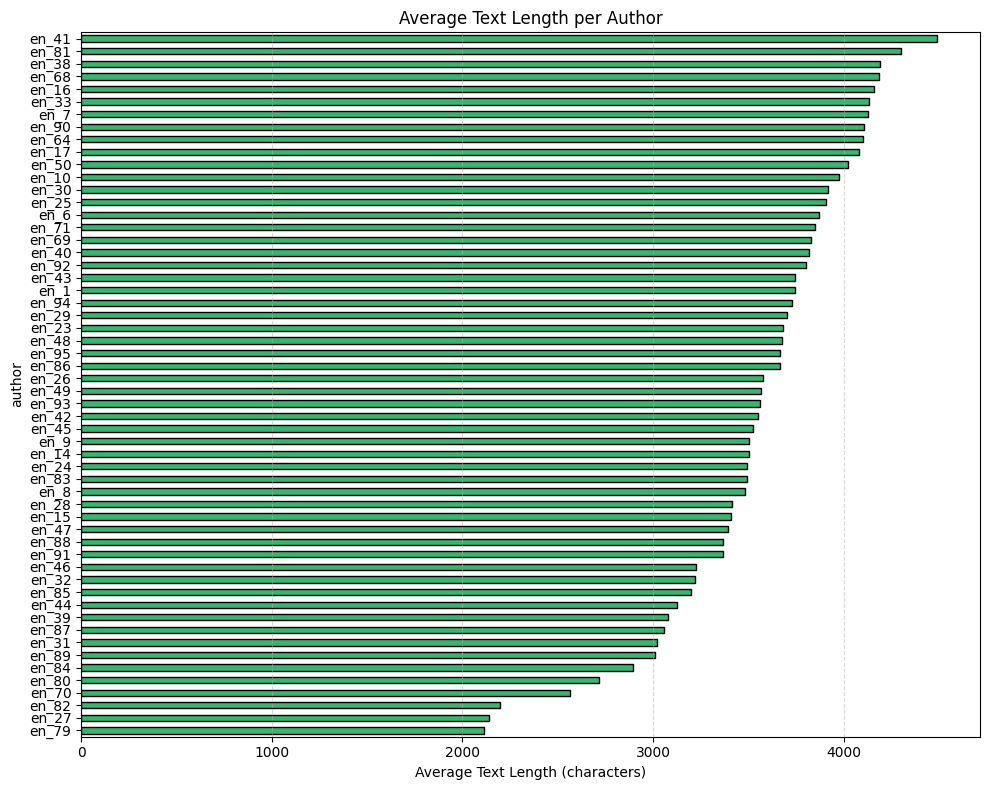

In [160]:
plot_avg_text_length_per_author(df_auth_text)

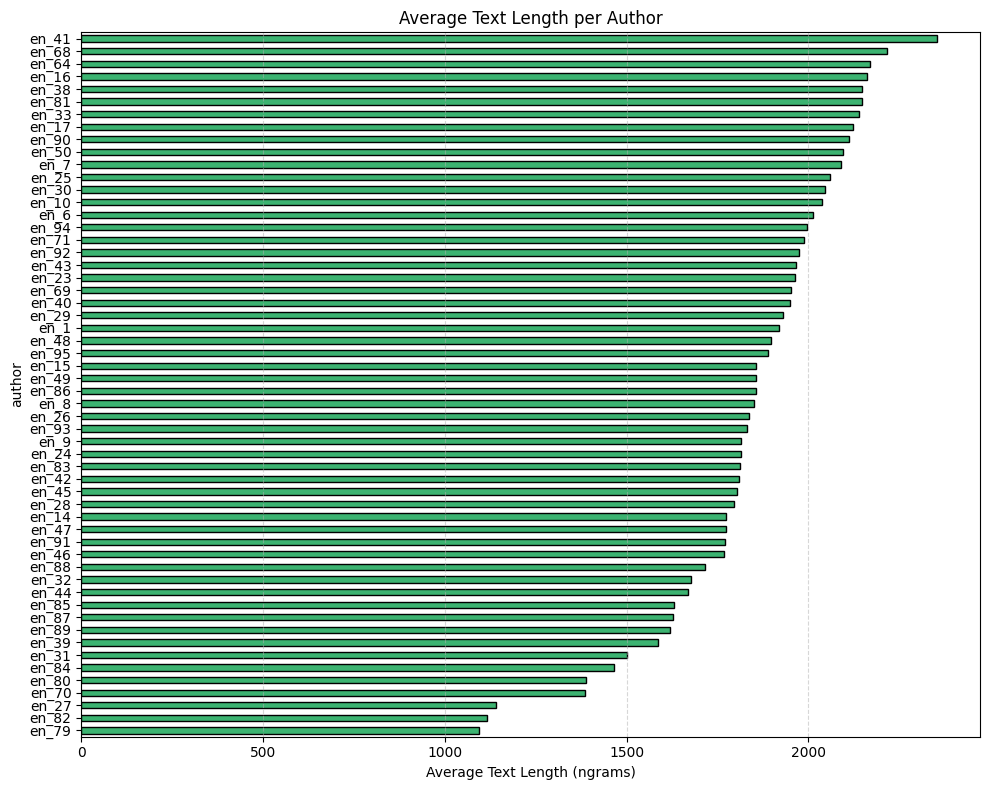

In [161]:
plot_avg_text_length_per_author(df_auth_text, unit='ngrams')

In [162]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_two_boxplots_in_same_axes(df):
    """
    Plot two boxplots side by side in the same plot:
    1) Average text length per author
    2) All text lengths
    Outliers on average lengths are annotated.

    Args:
        df (pd.DataFrame): DataFrame with 'author' and 'text' columns.
    """

    impostor_det = ImpostorDetector(ds_pan, top_n=250, portion_delete=0.5, shared_vocab_only=True, strict=True)
    df['n_ngram'] = df['text'].apply(lambda text: len(impostor_det.tokenize_char_ngrams(text, n=4, normalize_ws=True, space_free=True)))
    df['text_length'] = df['text'].str.len()
    
    avg_text_len = df.groupby('author')['text_length'].mean()
    avg_n_gram = df.groupby('author')['n_ngram'].mean()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Data for two boxplots vertically stacked (y=2 for text length, y=1 for ngram)
    data = [avg_text_len, avg_n_gram]
    positions = [2, 1]
    
    box = ax.boxplot(data, positions=positions, vert=False, widths=0.6, patch_artist=True)
    
    colors = ['lightblue', 'lightgreen']
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
    
    # Y-axis labels
    ax.set_yticks(positions)
    ax.set_yticklabels(['Avg Text Length per Author', 'Avg ngram Count per Author'])
    ax.set_xlabel('Value')
    ax.set_title('Boxplots of Average Text Length and ngram Count per Author')
    
    # Function to find and annotate outliers
    def annotate_outliers(variable, pos, color):
        Q1 = variable.quantile(0.25)
        Q3 = variable.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = variable[(variable < lower) | (variable > upper)]
        for author, val in outliers.items():
            ax.plot(val, pos, 'o', color=color)
            ax.text(val, pos + 0.1, author, rotation=45, ha='center', va='bottom', fontsize=8)
    
    # Annotate outliers in each boxplot
    annotate_outliers(avg_text_len, 2, 'blue')
    annotate_outliers(avg_n_gram, 1, 'green')
    
    # Legend for outliers
    ax.plot([], [], 'o', color='blue', label='Outliers in Avg Text Length')
    ax.plot([], [], 'o', color='green', label='Outliers in Avg ngram')
    ax.legend(loc='upper right')
    
    ax.set_ylim(0.5, 2.5)
    plt.tight_layout()
    plt.show()


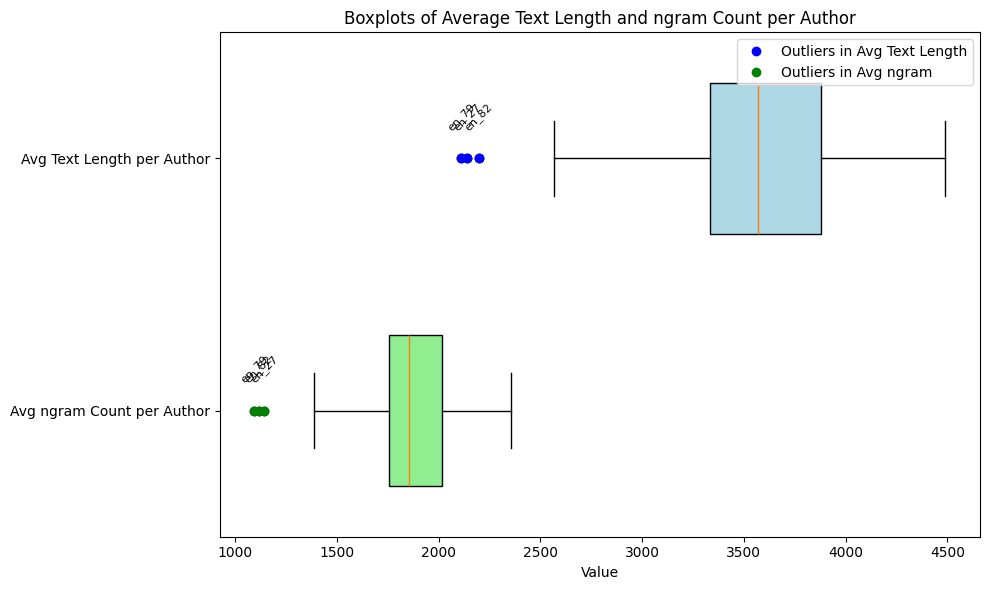

In [163]:
plot_two_boxplots_in_same_axes(df_auth_text)
